# Use of topic modeling to perform clustering on categories
### `>>` comparison of performance using metric: confidence score
### `>>` topic-document association --- strngth of topic fit

In [14]:
## load necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read in original biusiness dataset
bizdf = pd.read_csv('Data/business_output.csv')
bizdf.head(2)

/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/1762404966.py:2: DtypeWarning: Columns (12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  bizdf = pd.read_csv('Data/business_output.csv')


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.RestaurantsCounterService,attributes.AgesAllowed,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,NaN,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,NaN,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0


In [3]:
bizdf.categories

0         Doctors, Traditional Chinese Medicine, Naturop...
1         Shipping Centers, Local Services, Notaries, Ma...
2         Department Stores, Shopping, Fashion, Home & G...
3         Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4                                 Brewpubs, Breweries, Food
                                ...                        
150341                           Nail Salons, Beauty & Spas
150342    Pets, Nurseries & Gardening, Pet Stores, Hobby...
150343    Shopping, Jewelry, Piercing, Toy Stores, Beaut...
150344    Fitness/Exercise Equipment, Eyewear & Optician...
150345    Beauty & Spas, Permanent Makeup, Piercing, Tattoo
Name: categories, Length: 150346, dtype: object

In [4]:
bizdf.iloc[15]['categories']

'Sushi Bars, Restaurants, Japanese'

In [5]:
bizdf.iloc[55]['categories']

'Hotels, Hotels & Travel, Event Planning & Services'

In [6]:
bizdf.iloc[0]['categories']

'Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists'

In [ ]:
# # Quick start - try this first
def simple_topic_modeling(df, n_topics=5):
    """Simple topic modeling starter"""
    
    # Clean data
    df_clean = df.dropna(subset=['categories']).copy()
    df_clean['categories'] = df_clean['categories'].astype(str)
    
    # Vectorize
    tfidf = TfidfVectorizer(max_features=500, stop_words='english')
    X = tfidf.fit_transform(df_clean['categories'])
    
    # Topic modeling
    nmf = NMF(n_components=n_topics, random_state=42)
    topic_probs = nmf.fit_transform(X)
    
    # See what topics were discovered
    feature_names = tfidf.get_feature_names_out()
    
    print("Discovered Topics:")
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    
    df_clean['topic'] = topic_probs.argmax(axis=1)
    return df_clean, nmf, tfidf

# Run this to see what topics exist in your reviews
df_topics, model, vectorizer = simple_topic_modeling(bizdf)
print(f"Topic distribution:\n{df_topics['topic'].value_counts().sort_index()}")

Discovered Topics:
Topic 0: restaurants, bars, american, pizza, nightlife, traditional, new, italian, mexican, sandwiches
Topic 1: spas, beauty, salons, hair, nail, removal, barbers, waxing, massage, medical
Topic 2: services, home, event, hotels, planning, local, shopping, travel, estate, real
Topic 3: food, tea, coffee, fast, restaurants, burgers, sandwiches, bakeries, specialty, grocery
Topic 4: auto, automotive, repair, stations, car, tires, change, oil, dealers, parts
Topic distribution:
topic
0    35514
1    20712
2    54442
3    28727
4    10848
Name: count, dtype: int64


In [102]:
"""
main method for comprehensive topic analysis
- data cleaning
- TF-IDF vectorization
- NMF topic modeling
- topic assignment
- topic quality analysis
- topic-star rating relationship analysis
"""

def comprehensive_topic_analysis(df, text_column='categories', n_topics=5):
    """Comprehensive topic modeling with visualization"""
    
    # Clean data
    df_clean = df.dropna(subset=[text_column]).copy()
    df_clean[text_column] = df_clean[text_column].astype(str)
    df_clean = df_clean[df_clean[text_column].str.strip() != '']
    
    # Create TF-IDF matrix
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=2, max_df=0.8)
    tfidf_matrix = tfidf.fit_transform(df_clean[text_column])
    feature_names = tfidf.get_feature_names_out()
    
    # Apply NMF
    nmf = NMF(n_components=n_topics, random_state=42, max_iter=1000)
    W = nmf.fit_transform(tfidf_matrix)  # Document-topic matrix
    topic_term_mat = nmf.components_  # Topic-term matrix
    
    # Assign topics
    df_clean['dominant_topic'] = W.argmax(axis=1)
    df_clean['topic_confidence'] = W.max(axis=1)
    
    # Analyze and visualize topics
    print("Discovered Topics:")
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    plot_topics(topic_term_mat, feature_names, n_top_words=10)
    analyze_topic_quality(df_clean, W)
    topic_star_analysis(df_clean)
    
    return df_clean, nmf, tfidf

def plot_topics(H, feature_names, n_top_words=10):
    """Display the top words for each topic"""
    fig, axes = plt.subplots(4, 4, figsize=(15, 10))
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(H):
        if topic_idx < len(axes):
            # Get top words for this topic
            top_features_ind = topic.argsort()[:-n_top_words-1:-1]
            top_features = [feature_names[i] for i in top_features_ind]
            weights = topic[top_features_ind]
            
            # Plot
            axes[topic_idx].barh(range(n_top_words), weights)
            axes[topic_idx].set_yticks(range(n_top_words))
            axes[topic_idx].set_yticklabels(top_features)
            axes[topic_idx].set_title(f'Topic {topic_idx}')
            axes[topic_idx].set_xlabel('Weight')
    
    # Hide empty subplots
    for i in range(len(H), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_topic_quality(df_clean, W):
    """Analyze topic distribution and quality"""
    print("=== Topic Analysis ===")
    topic_counts = df_clean['dominant_topic'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    topic_counts.plot(kind='bar')
    plt.title('Topic Distribution')
    plt.xlabel('Topic ID')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=0)
    plt.show()
    
    overall_weighted_confidence_across_all_clusters = 0
    print("Topic distribution:")
    for topic_id, count in topic_counts.items():
        avg_confidence = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].mean()
        review_count = df_clean[df_clean['dominant_topic'] == topic_id]['topic_confidence'].count()
        overall_weighted_confidence_across_all_clusters += avg_confidence*review_count
        print(f"Topic {topic_id}: {count} reviews (avg confidence: {avg_confidence:.3f})")
    
    overall_weighted_confidence_across_all_clusters = overall_weighted_confidence_across_all_clusters/df_clean.shape[0]
    print(f"overall_weighted_confidence_across_all_clusters {overall_weighted_confidence_across_all_clusters:.4f}")


    return overall_weighted_confidence_across_all_clusters

def topic_star_analysis(df_clean):
    """Analyze relationship between topics and star ratings with integer stars"""
    if 'stars' in df_clean.columns:
        print("\n=== Topic-Star Rating Relationship ===")
        
        # Ensure stars are integers and filter only 1-5
        df_clean = df_clean.copy()
        df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
        df_clean = df_clean.dropna(subset=['stars'])
        df_clean['stars'] = df_clean['stars'].astype(int)
        df_clean = df_clean[df_clean['stars'].between(1, 5)]
        
        print(f"Analyzing {len(df_clean)} reviews with star ratings 1-5")
        
        # 1. Cross-tabulation with proper integer stars
        cross_tab = pd.crosstab(df_clean['dominant_topic'], df_clean['stars'])
        
        # Reindex to ensure all star ratings 1-5 are included
        all_stars = range(1, 6)
        cross_tab = cross_tab.reindex(columns=all_stars, fill_value=0)
        
        # Plot stacked bar chart
        plt.figure(figsize=(12, 8))
        ax = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8), 
                           color=['#ff6b6b', '#ffa726', '#ffee58', '#9ccc65', '#42a5f5'])
        plt.title('Topic Distribution by Star Rating', fontsize=14, fontweight='bold')
        plt.xlabel('Topic', fontsize=12)
        plt.ylabel('Number of Reviews', fontsize=12)
        plt.legend(title='Star Rating', labels=[f'⭐{star}' for star in all_stars])
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, label_type='center', fmt='%d', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Topic sentiment analysis with integer stars
        topic_avg_rating = df_clean.groupby('dominant_topic')['stars'].mean()
        topic_rating_std = df_clean.groupby('dominant_topic')['stars'].std()
        topic_counts = df_clean.groupby('dominant_topic').size()
        
        print("\n=== Topic Analysis Summary ===")
        for topic in sorted(topic_avg_rating.index):
            avg_rating = topic_avg_rating[topic]
            std_rating = topic_rating_std[topic]
            count = topic_counts[topic]
            
            print(f"Topic {topic}: {avg_rating:.2f} ± {std_rating:.2f} stars ({count} reviews)")
        
        # 3. Plot average star rating by topic
        plt.figure(figsize=(10, 6))
        topics_sorted = sorted(topic_avg_rating.index)
        avg_ratings = [topic_avg_rating[topic] for topic in topics_sorted]
        colors = ['red' if rating < 2.5 else 'orange' if rating < 3.5 else 'green' for rating in avg_ratings]
        
        bars = plt.bar([f'Topic {topic}' for topic in topics_sorted], avg_ratings, 
                      color=colors, alpha=0.7, edgecolor='black')
        
        plt.title('Average Star Rating by Topic', fontsize=14, fontweight='bold')
        plt.ylabel('Average Star Rating', fontsize=12)
        plt.ylim(0, 5.5)
        plt.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, rating in zip(bars, avg_ratings):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{rating:.2f}⭐', ha='center', va='bottom', fontweight='bold')
        
        # Add horizontal line at neutral rating (2.5)
        plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.5, label='Neutral (2.5)')
        plt.axhline(y=3.5, color='green', linestyle='--', alpha=0.5, label='Positive (3.5)')
        plt.legend()
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # 4. Heatmap of topic-star correlation
        plt.figure(figsize=(10, 6))
        
        # Calculate percentage distribution
        cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        
        sns.heatmap(cross_tab_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
                   cbar_kws={'label': 'Percentage (%)'})
        plt.title('Topic-Star Rating Distribution (%)', fontsize=14, fontweight='bold')
        plt.xlabel('Star Rating', fontsize=12)
        plt.ylabel('Topic', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        return {
            'cross_tab': cross_tab,
            'avg_ratings': topic_avg_rating,
            'topic_counts': topic_counts
        }



`weighted confidence` formula

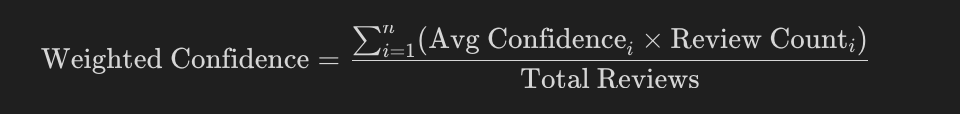

## 1. Set as 6 topics distribution

Discovered Topics:
Topic 0: bars, american, nightlife, traditional, new, restaurants, sports, breakfast, brunch, pubs
Topic 1: spas, beauty, salons, hair, nail, removal, barbers, waxing, massage, day
Topic 2: services, home, event, hotels, planning, travel, estate, real, local, shopping
Topic 3: food, tea, coffee, fast, burgers, restaurants, bakeries, grocery, sandwiches, specialty
Topic 4: auto, automotive, repair, stations, car, tires, change, oil, dealers, parts
Topic 5: restaurants, pizza, italian, mexican, sandwiches, chinese, chicken, wings, salad, fast


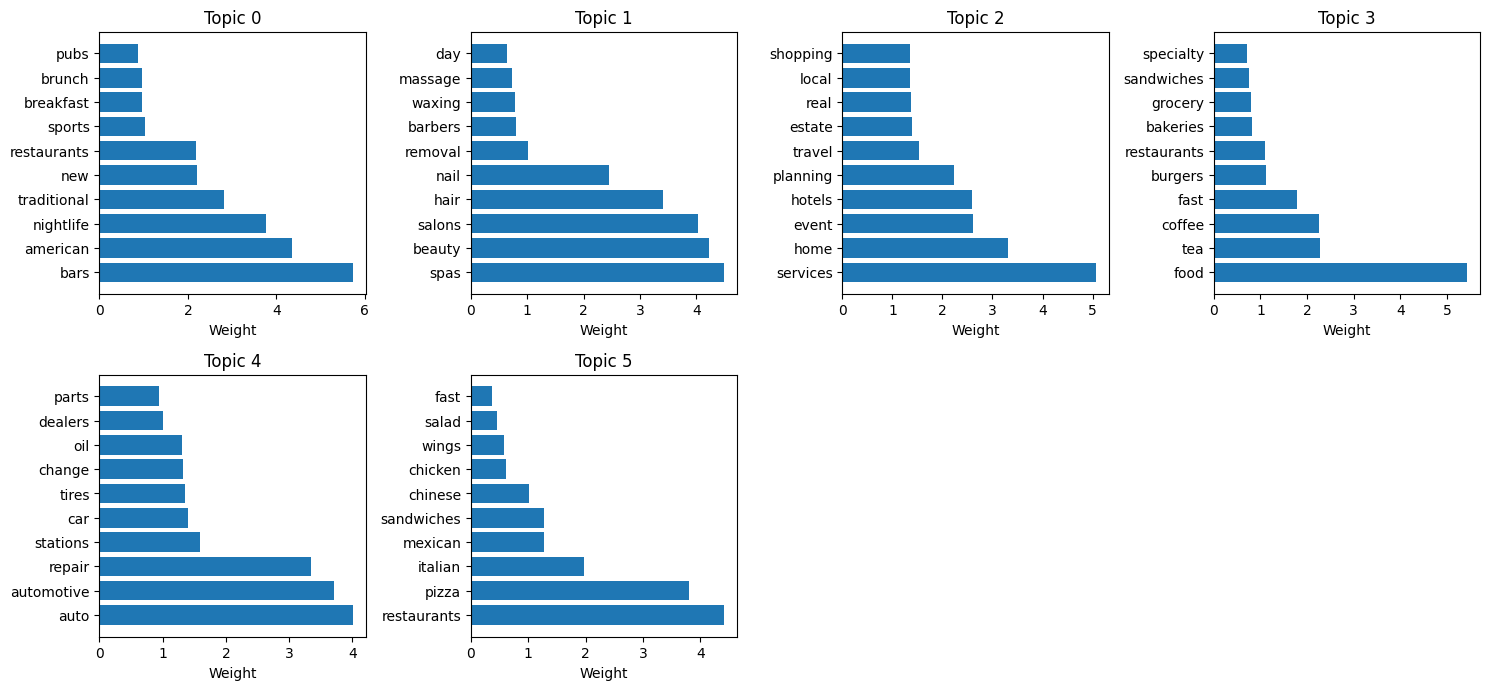

=== Topic Analysis ===


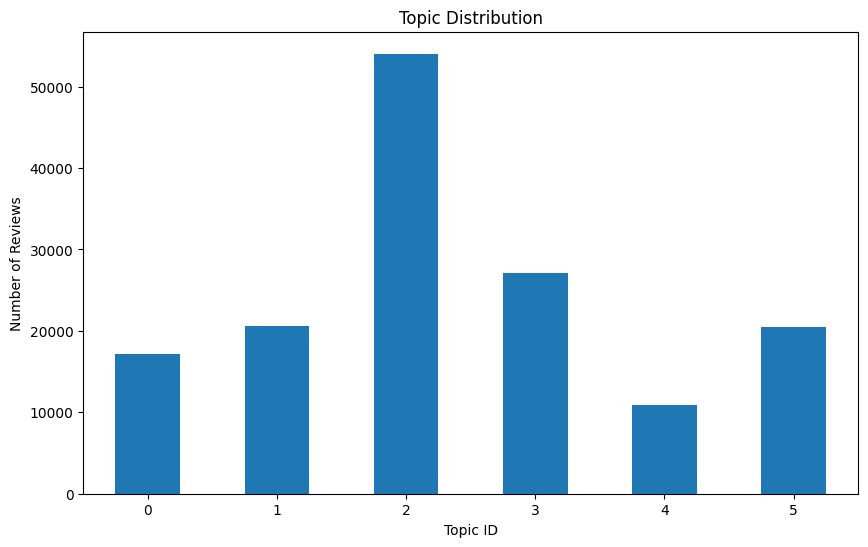

Topic distribution:
Topic 0: 17138 reviews (avg confidence: 0.049)
Topic 1: 20614 reviews (avg confidence: 0.049)
Topic 2: 54039 reviews (avg confidence: 0.027)
Topic 3: 27138 reviews (avg confidence: 0.055)
Topic 4: 10868 reviews (avg confidence: 0.071)
Topic 5: 20446 reviews (avg confidence: 0.058)
overall_weighted_confidence_across_all_clusters 0.0449

=== Topic-Star Rating Relationship ===
Analyzing 150243 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:133: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


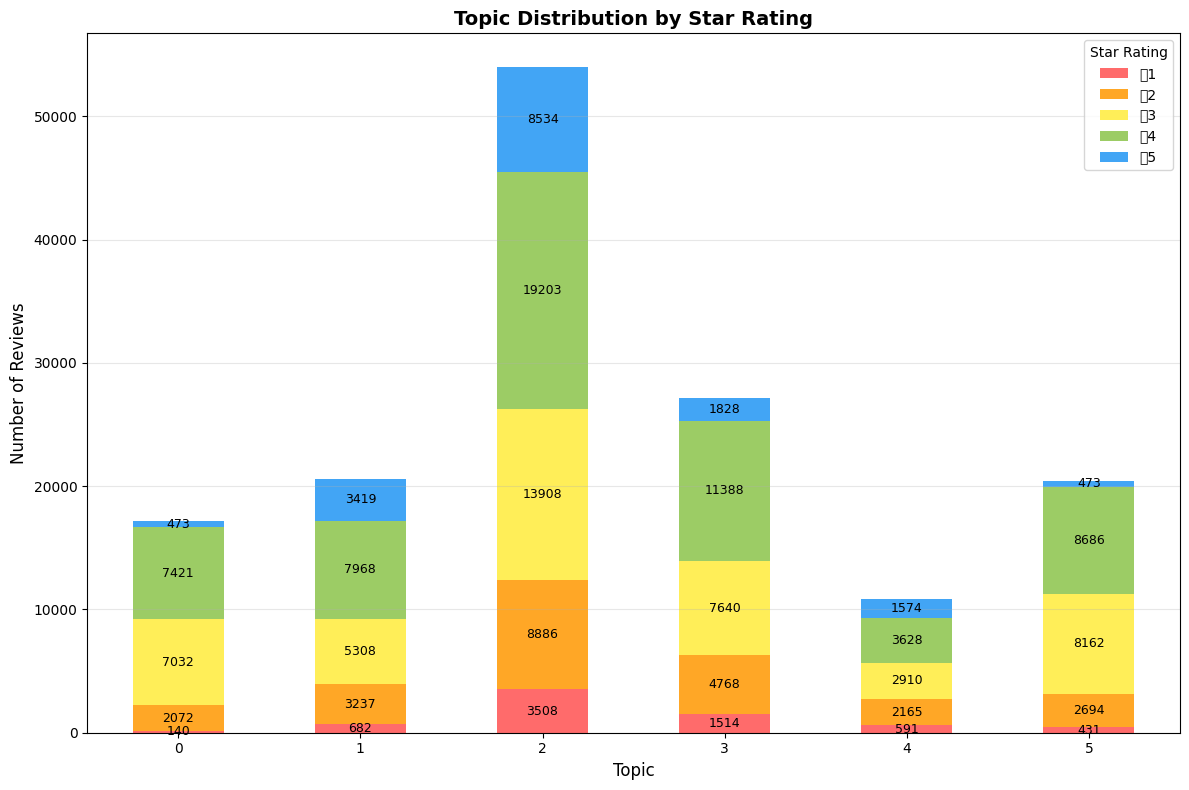


=== Topic Analysis Summary ===
Topic 0: 3.35 ± 0.76 stars (17138 reviews)
Topic 1: 3.50 ± 1.05 stars (20614 reviews)
Topic 2: 3.38 ± 1.13 stars (54039 reviews)
Topic 3: 3.27 ± 1.01 stars (27138 reviews)
Topic 4: 3.32 ± 1.11 stars (10868 reviews)
Topic 5: 3.30 ± 0.80 stars (20446 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:174: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


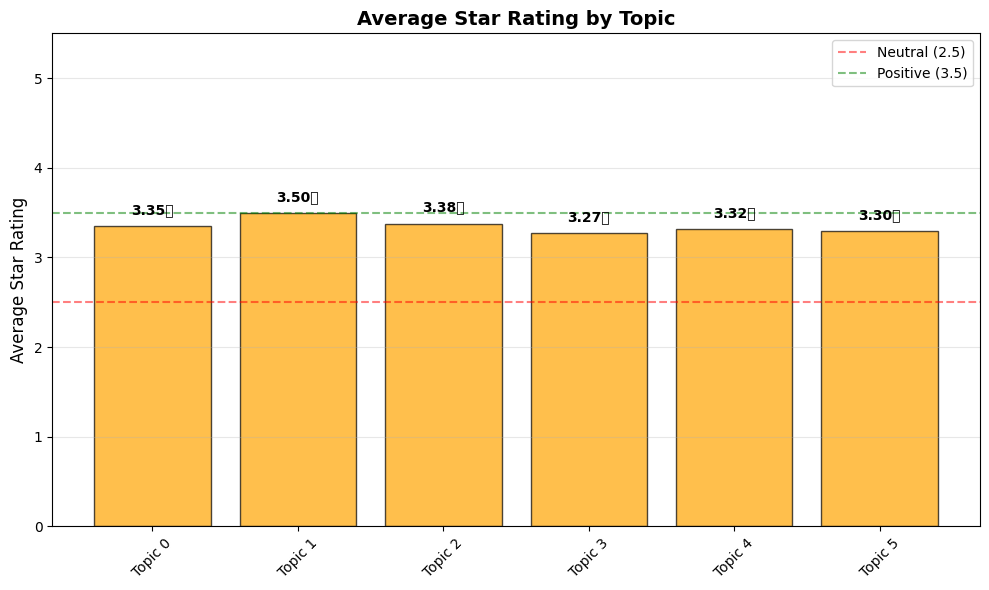

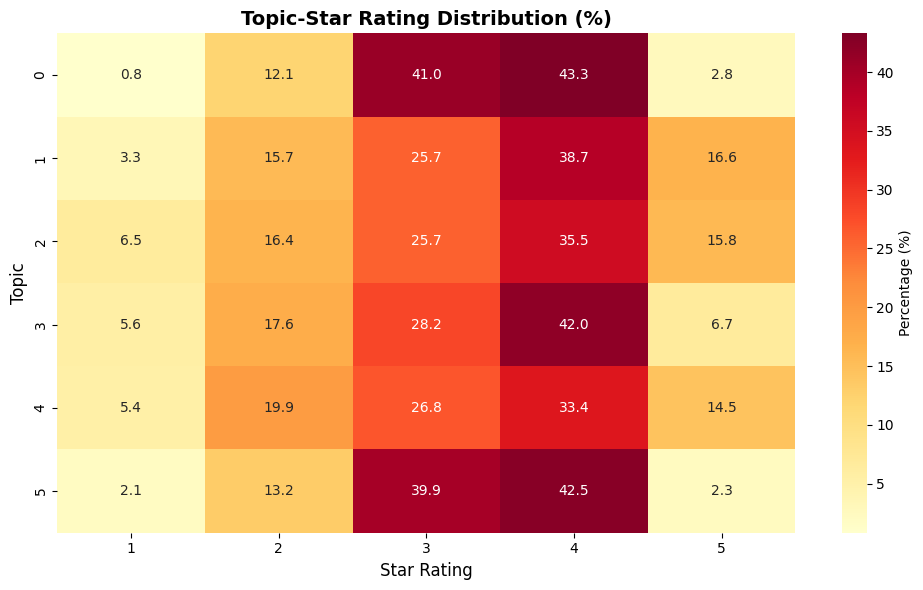

(                   business_id                      name  \
 0       Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
 1       mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
 2       tUFrWirKiKi_TAnsVWINQQ                    Target   
 3       MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   
 ...                        ...                       ...   
 150341  IUQopTMmYQG-qRtBk-8QnA              Binh's Nails   
 150342  c8GjPIOTGVmIemT7j5_SyQ      Wild Birds Unlimited   
 150343  _QAMST-NrQobXduilWEqSw         Claire's Boutique   
 150344  mtGm22y5c2UHNXDFAjaPNw  Cyclery & Fitness Center   
 150345  jV_XOycEzSlTx-65W906pg                   Sic Ink   
 
                                 address           city state postal_code  \
 0                1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
 1       87 Grasso Plaza Shopping Center         Affton    MO       63123   
 2                  5255 E Broadway

In [97]:
comprehensive_topic_analysis(bizdf, n_topics=6)

In [31]:
# map dominant topic to categories
df_clusteredBIZ = df_topics.copy()
df_clusteredBIZ['topic_category'] = df_clusteredBIZ['topic'].map({0: 'Food & Dining',
                                 1: 'Health & Medical',
                                 2: 'Shopping',
                                 3: 'Automotive',
                                 4: 'Home Services',
                                 5: 'Beauty & Spas'})       
df_clusteredBIZ.head(2)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,attributes.DietaryRestrictions,hours.Monday,hours.Tuesday,hours.Wednesday,hours.Thursday,hours.Friday,hours.Saturday,hours.Sunday,topic,topic_category
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,NaN,0:0-0:0,8:0-18:30,8:0-18:30,8:0-18:30,8:0-18:30,8:0-14:0,NaN,0,Food & Dining
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,NaN,8:0-22:0,8:0-22:0,8:0-22:0,8:0-22:0,8:0-23:0,8:0-23:0,8:0-22:0,2,Shopping


## 2. Set 8 clusters

Discovered Topics:
Topic 0: bars, american, nightlife, traditional, new, restaurants, sports, brunch, breakfast, pubs
Topic 1: spas, beauty, salons, hair, nail, removal, barbers, waxing, day, massage
Topic 2: home, services, estate, real, shopping, local, garden, stores, apartments, pet
Topic 3: food, tea, coffee, fast, burgers, restaurants, bakeries, grocery, sandwiches, specialty
Topic 4: auto, automotive, repair, stations, car, tires, change, oil, dealers, parts
Topic 5: restaurants, pizza, italian, mexican, sandwiches, chinese, chicken, wings, salad, fast
Topic 6: hotels, event, planning, travel, services, venues, spaces, caterers, party, arts
Topic 7: medical, health, dentists, doctors, dentistry, general, cosmetic, massage, centers, therapy


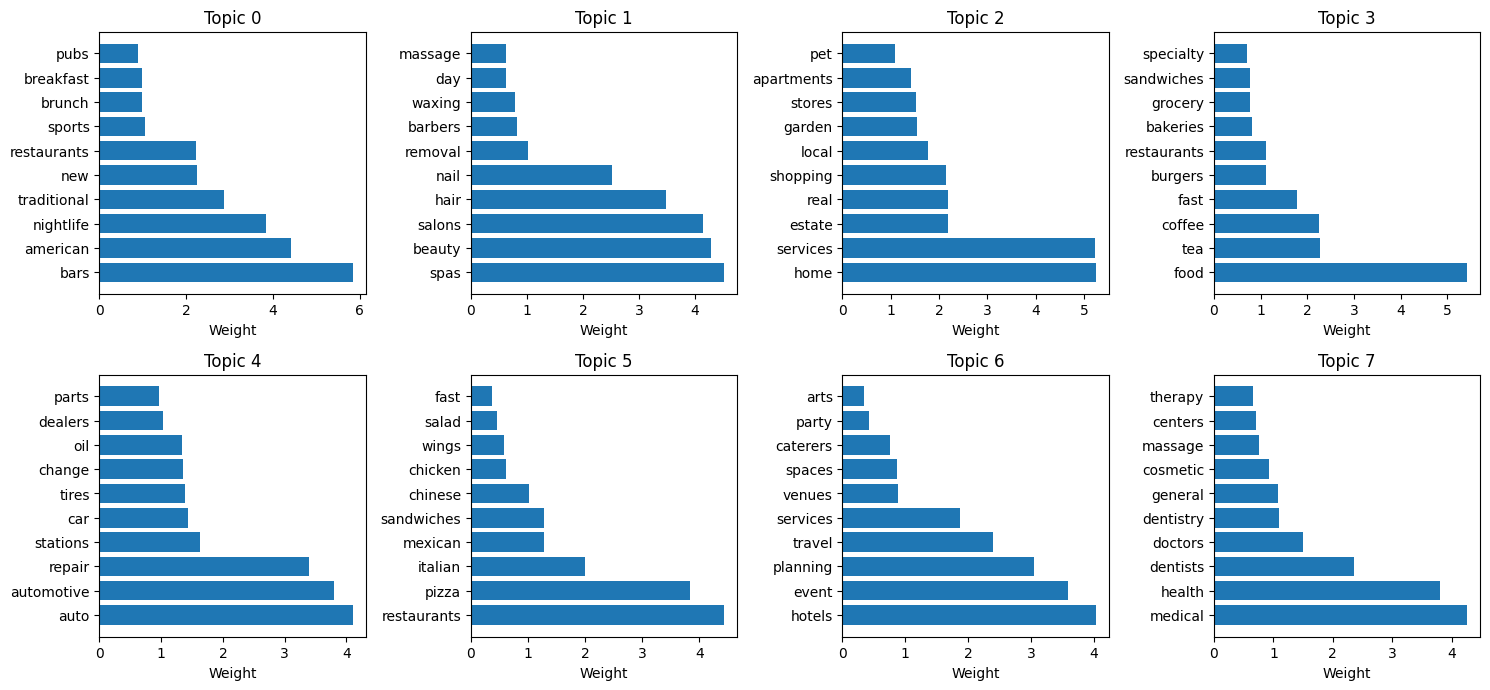

=== Topic Analysis ===


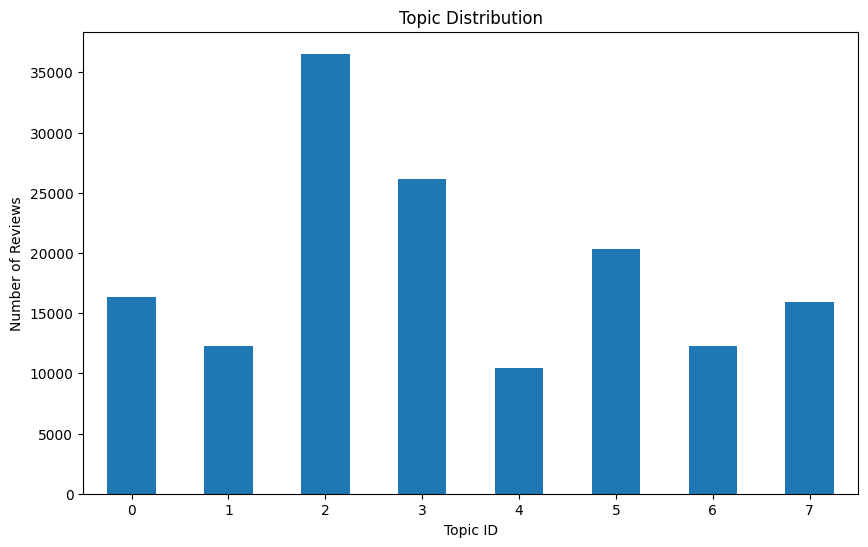

Topic distribution:
Topic 0: 16352 reviews (avg confidence: 0.049)
Topic 1: 12309 reviews (avg confidence: 0.073)
Topic 2: 36545 reviews (avg confidence: 0.029)
Topic 3: 26153 reviews (avg confidence: 0.056)
Topic 4: 10421 reviews (avg confidence: 0.071)
Topic 5: 20306 reviews (avg confidence: 0.058)
Topic 6: 12267 reviews (avg confidence: 0.064)
Topic 7: 15890 reviews (avg confidence: 0.049)
overall_weighted_confidence_across_all_clusters 0.0513

=== Topic-Star Rating Relationship ===
Analyzing 150243 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:133: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


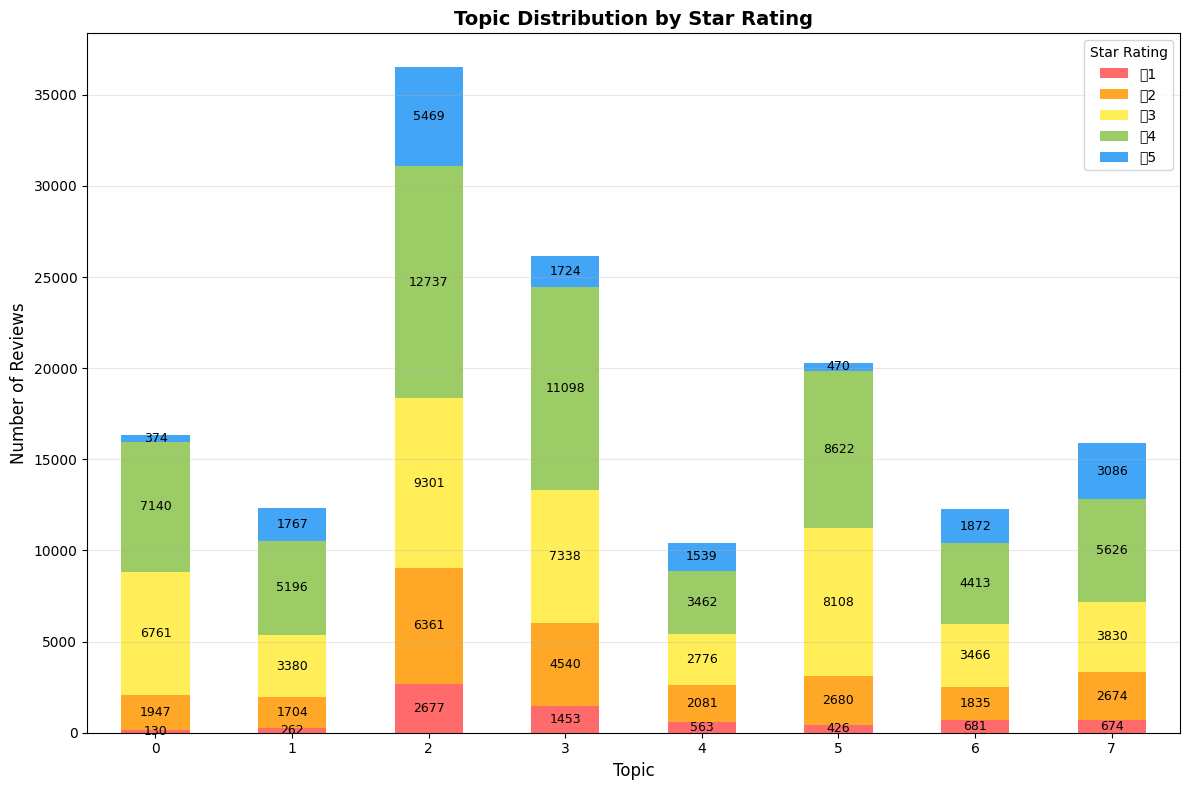


=== Topic Analysis Summary ===
Topic 0: 3.35 ± 0.75 stars (16352 reviews)
Topic 1: 3.53 ± 0.97 stars (12309 reviews)
Topic 2: 3.33 ± 1.14 stars (36545 reviews)
Topic 3: 3.27 ± 1.01 stars (26153 reviews)
Topic 4: 3.32 ± 1.11 stars (10421 reviews)
Topic 5: 3.30 ± 0.80 stars (20306 reviews)
Topic 6: 3.40 ± 1.09 stars (12267 reviews)
Topic 7: 3.49 ± 1.11 stars (15890 reviews)


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:174: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


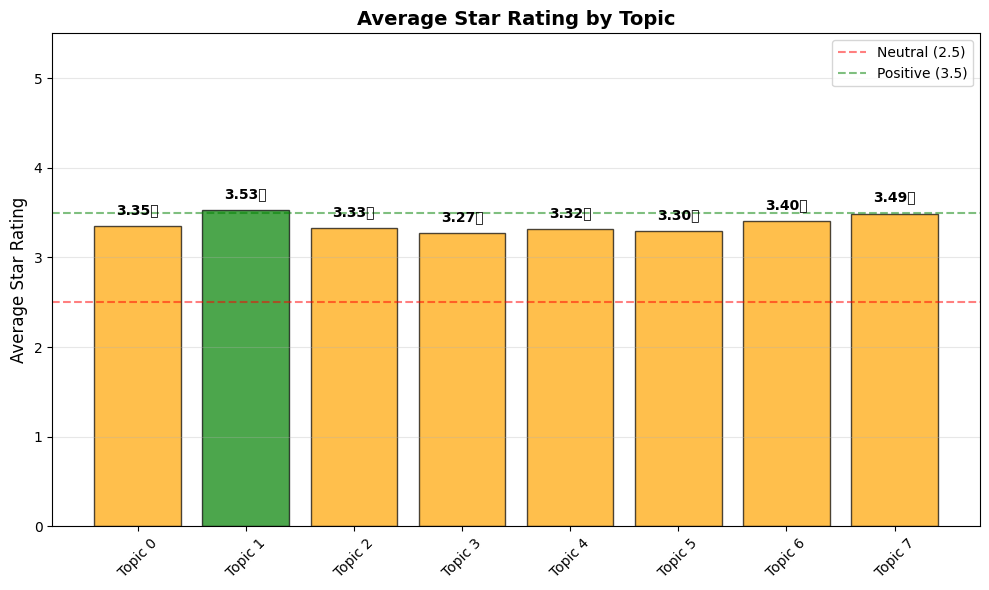

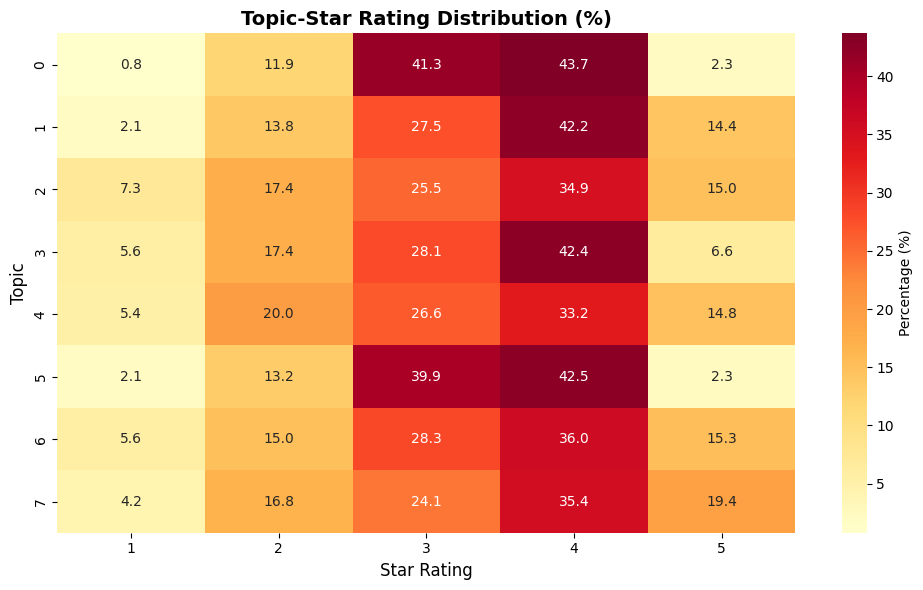

(                   business_id                      name  \
 0       Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
 1       mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
 2       tUFrWirKiKi_TAnsVWINQQ                    Target   
 3       MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   
 ...                        ...                       ...   
 150341  IUQopTMmYQG-qRtBk-8QnA              Binh's Nails   
 150342  c8GjPIOTGVmIemT7j5_SyQ      Wild Birds Unlimited   
 150343  _QAMST-NrQobXduilWEqSw         Claire's Boutique   
 150344  mtGm22y5c2UHNXDFAjaPNw  Cyclery & Fitness Center   
 150345  jV_XOycEzSlTx-65W906pg                   Sic Ink   
 
                                 address           city state postal_code  \
 0                1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
 1       87 Grasso Plaza Shopping Center         Affton    MO       63123   
 2                  5255 E Broadway

In [99]:
comprehensive_topic_analysis(bizdf, n_topics=8)

## 3. Set 12 clusters

Discovered Topics:
Topic 0: bars, nightlife, sports, pubs, wine, cocktail, beer, sushi, lounges, entertainment
Topic 1: spas, beauty, salons, hair, nail, removal, barbers, waxing, day, massage
Topic 2: services, home, estate, real, local, apartments, cleaning, contractors, garden, laundry
Topic 3: food, tea, coffee, fast, burgers, bakeries, sandwiches, restaurants, grocery, specialty
Topic 4: auto, automotive, repair, stations, car, tires, change, oil, dealers, parts
Topic 5: pizza, restaurants, italian, sandwiches, chicken, wings, salad, delis, cheesesteaks, seafood
Topic 6: hotels, event, planning, travel, services, venues, spaces, caterers, party, arts
Topic 7: medical, health, dentists, doctors, dentistry, general, cosmetic, massage, centers, therapy
Topic 8: american, traditional, new, restaurants, breakfast, brunch, burgers, diners, sandwiches, seafood
Topic 9: shopping, stores, fashion, clothing, garden, home, women, department, furniture, accessories
Topic 10: pet, pets, groome

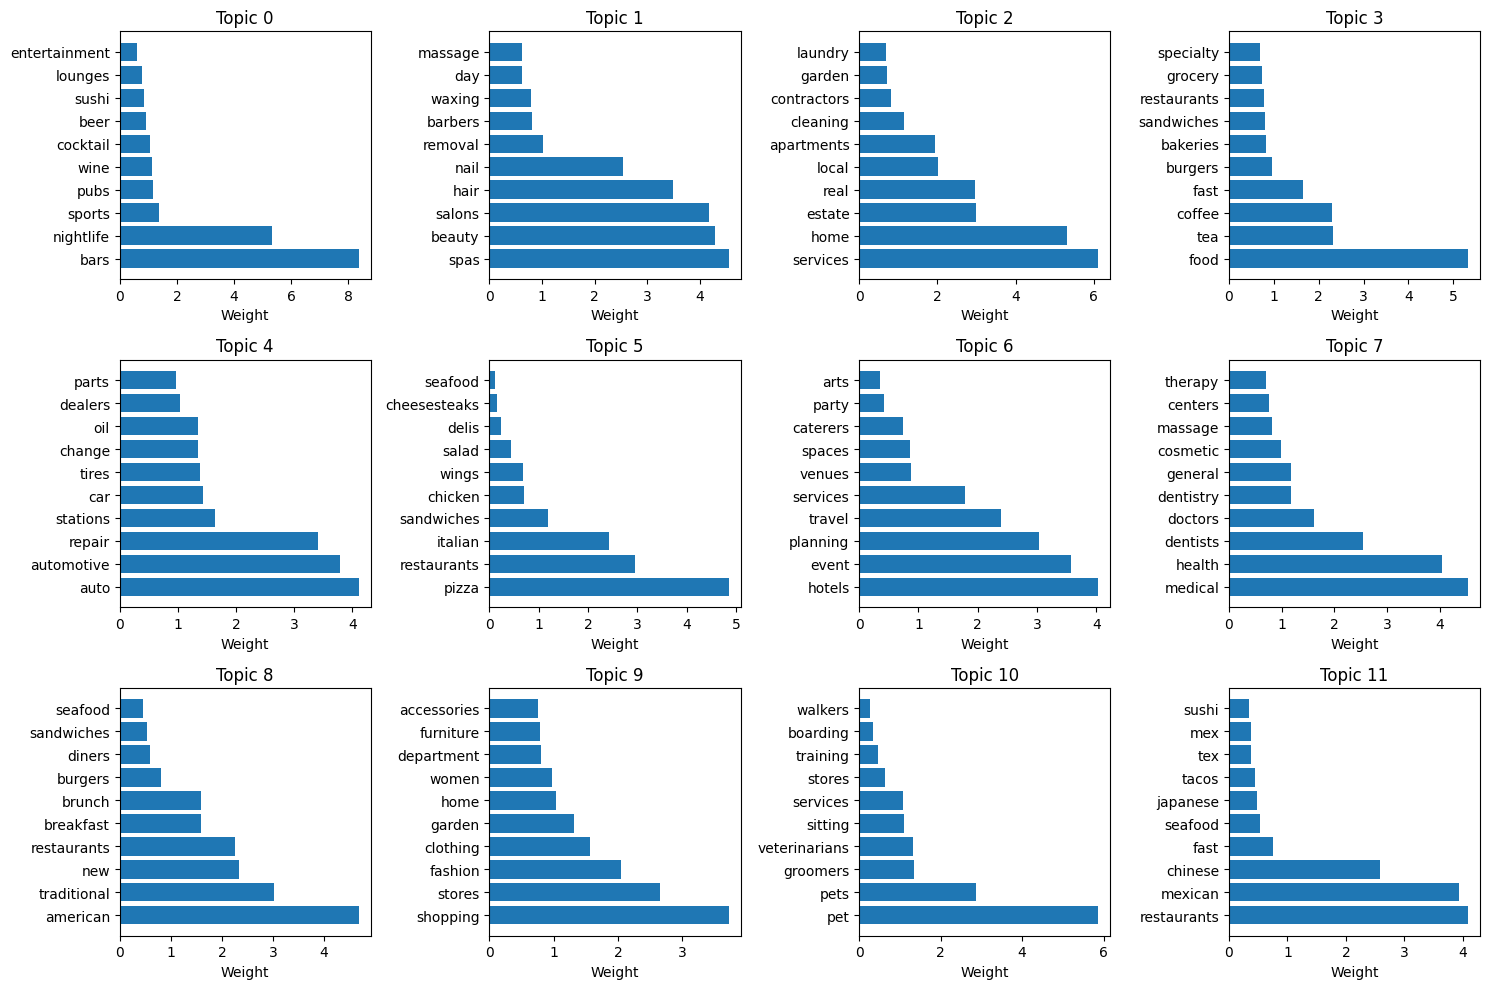

=== Topic Analysis ===


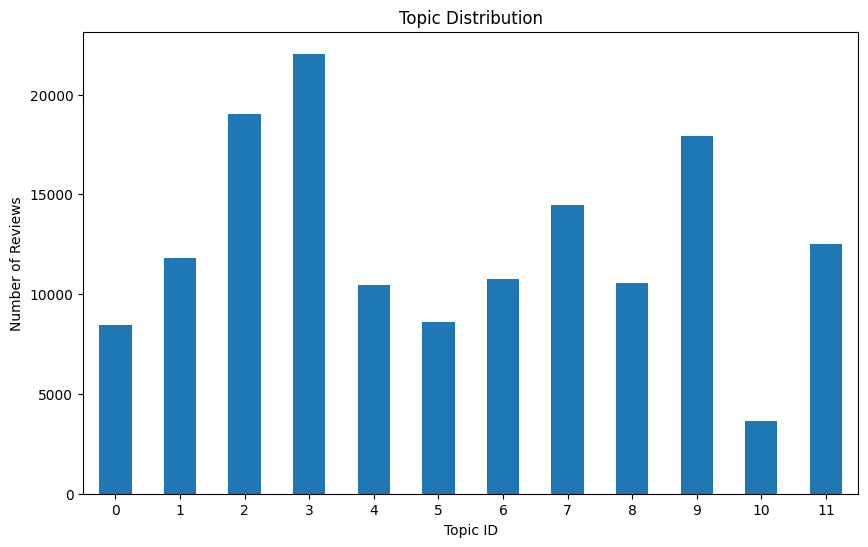

Topic distribution:
Topic 0: 8442 reviews (avg confidence: 0.051)
Topic 1: 11796 reviews (avg confidence: 0.074)
Topic 2: 19006 reviews (avg confidence: 0.036)
Topic 3: 22048 reviews (avg confidence: 0.060)
Topic 4: 10454 reviews (avg confidence: 0.071)
Topic 5: 8597 reviews (avg confidence: 0.091)
Topic 6: 10753 reviews (avg confidence: 0.070)
Topic 7: 14481 reviews (avg confidence: 0.049)
Topic 8: 10568 reviews (avg confidence: 0.074)
Topic 9: 17922 reviews (avg confidence: 0.051)
Topic 10: 3657 reviews (avg confidence: 0.106)
Topic 11: 12519 reviews (avg confidence: 0.058)
overall_weighted_confidence_across_all_clusters 0.0607

=== Topic-Star Rating Relationship ===
Analyzing 150243 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:133: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


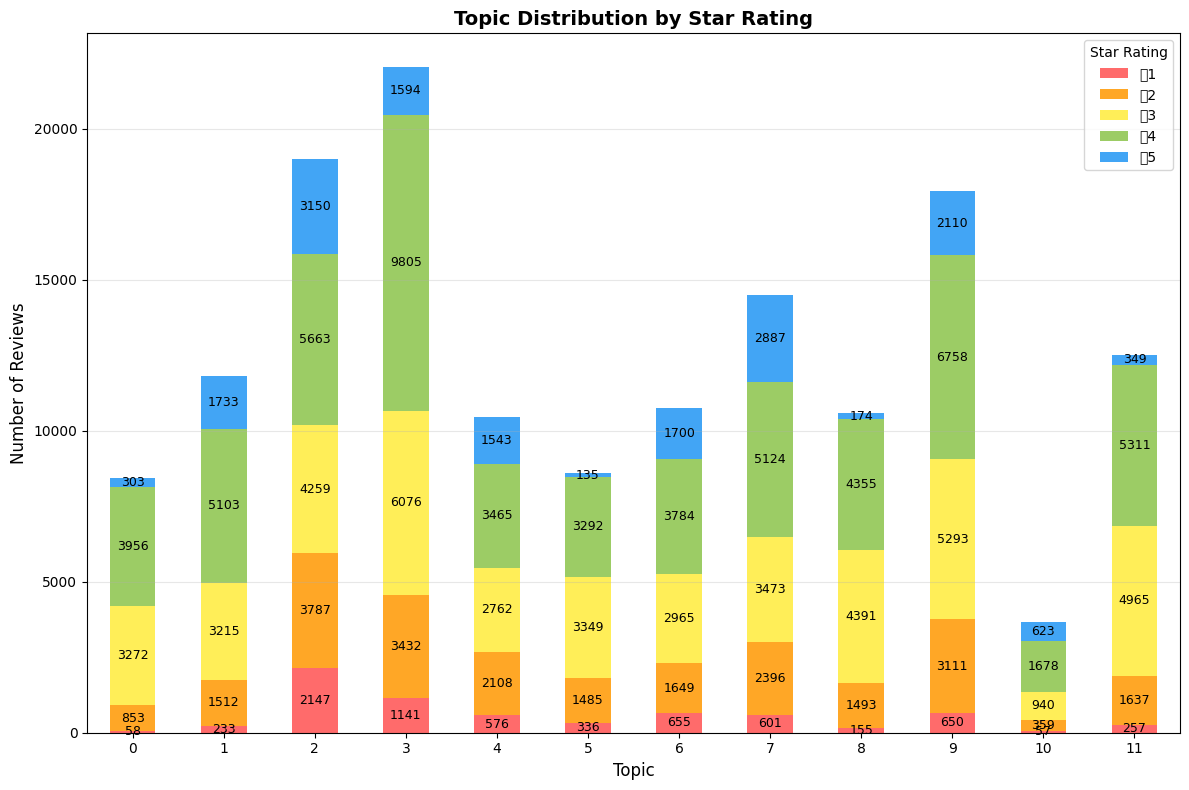

/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/3209641035.py:174: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



=== Topic Analysis Summary ===
Topic 0: 3.43 ± 0.75 stars (8442 reviews)
Topic 1: 3.56 ± 0.96 stars (11796 reviews)
Topic 2: 3.20 ± 1.25 stars (19006 reviews)
Topic 3: 3.33 ± 0.99 stars (22048 reviews)
Topic 4: 3.31 ± 1.12 stars (10454 reviews)
Topic 5: 3.16 ± 0.86 stars (8597 reviews)
Topic 6: 3.39 ± 1.11 stars (10753 reviews)
Topic 7: 3.50 ± 1.11 stars (14481 reviews)
Topic 8: 3.27 ± 0.78 stars (10568 reviews)
Topic 9: 3.37 ± 1.02 stars (17922 reviews)
Topic 10: 3.67 ± 0.92 stars (3657 reviews)
Topic 11: 3.31 ± 0.81 stars (12519 reviews)


/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


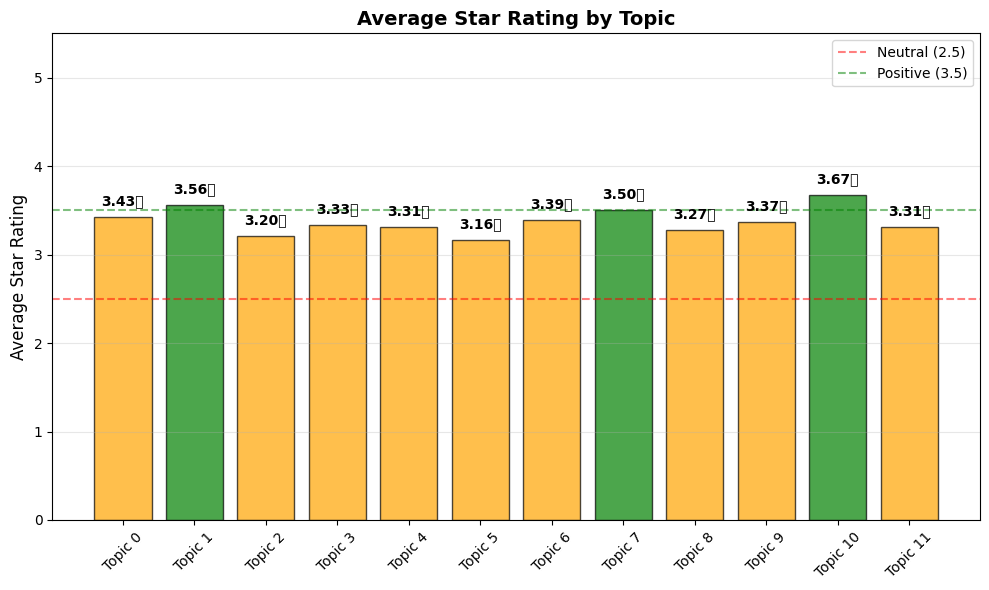

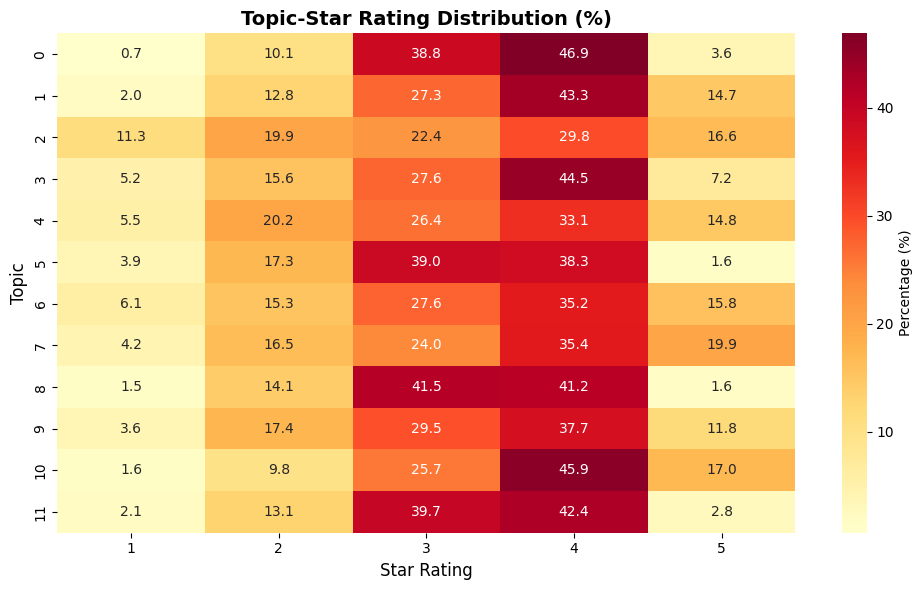

(                   business_id                      name  \
 0       Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
 1       mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
 2       tUFrWirKiKi_TAnsVWINQQ                    Target   
 3       MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   
 ...                        ...                       ...   
 150341  IUQopTMmYQG-qRtBk-8QnA              Binh's Nails   
 150342  c8GjPIOTGVmIemT7j5_SyQ      Wild Birds Unlimited   
 150343  _QAMST-NrQobXduilWEqSw         Claire's Boutique   
 150344  mtGm22y5c2UHNXDFAjaPNw  Cyclery & Fitness Center   
 150345  jV_XOycEzSlTx-65W906pg                   Sic Ink   
 
                                 address           city state postal_code  \
 0                1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
 1       87 Grasso Plaza Shopping Center         Affton    MO       63123   
 2                  5255 E Broadway

In [100]:
comprehensive_topic_analysis(bizdf, n_topics=12)

## 4. Set as 15 clusters 

Discovered Topics:
Topic 0: bars, nightlife, sports, pubs, wine, cocktail, beer, sushi, lounges, entertainment
Topic 1: spas, beauty, salons, hair, nail, removal, barbers, waxing, day, massage
Topic 2: services, home, local, cleaning, laundry, repair, contractors, professional, movers, dry
Topic 3: food, fast, burgers, grocery, sandwiches, restaurants, specialty, ice, frozen, yogurt
Topic 4: auto, automotive, repair, stations, car, tires, change, oil, dealers, parts
Topic 5: pizza, restaurants, italian, sandwiches, chicken, wings, salad, delis, cheesesteaks, seafood
Topic 6: hotels, event, planning, travel, services, venues, spaces, caterers, party, rental
Topic 7: medical, health, dentists, doctors, dentistry, general, cosmetic, massage, centers, surgeons
Topic 8: american, traditional, new, restaurants, brunch, breakfast, burgers, diners, sandwiches, seafood
Topic 9: shopping, stores, fashion, clothing, garden, home, women, furniture, department, accessories
Topic 10: pet, pets, groo

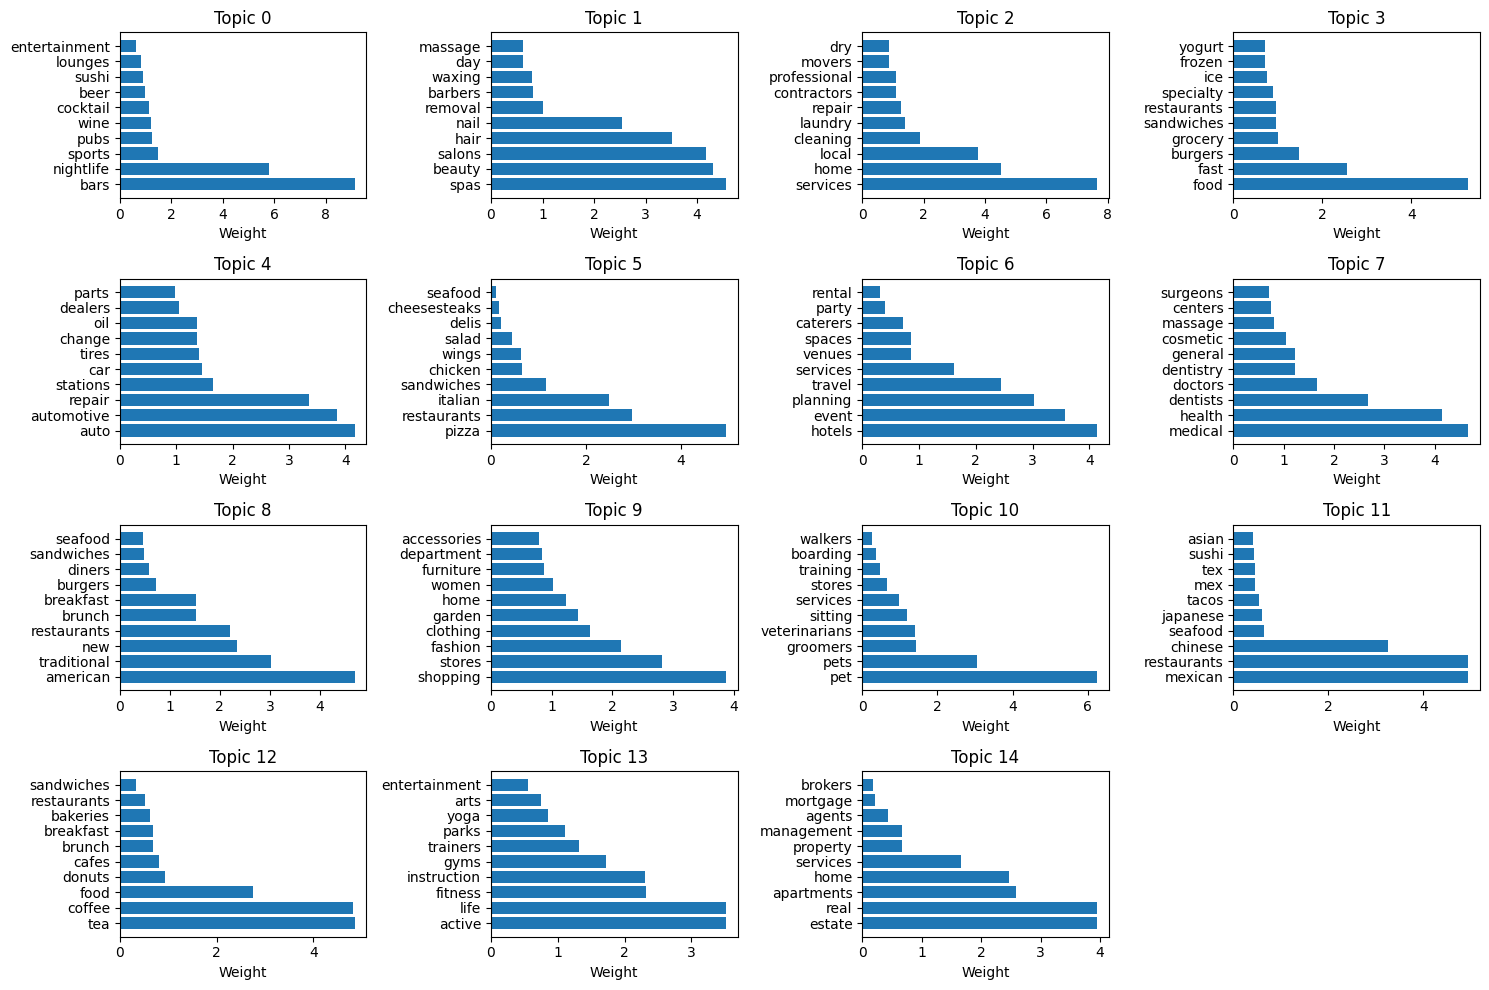

=== Topic Analysis ===


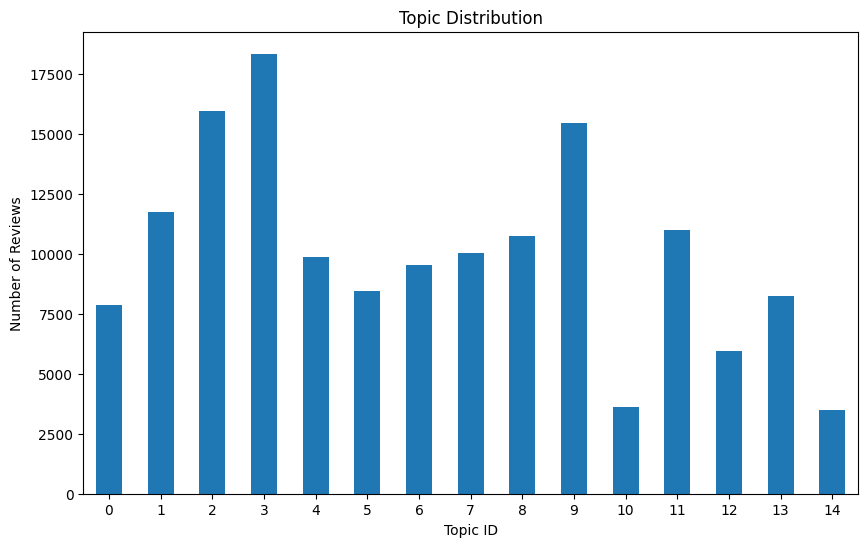

Topic distribution:
Topic 0: 7860 reviews (avg confidence: 0.048)
Topic 1: 11750 reviews (avg confidence: 0.074)
Topic 2: 15950 reviews (avg confidence: 0.033)
Topic 3: 18324 reviews (avg confidence: 0.059)
Topic 4: 9857 reviews (avg confidence: 0.073)
Topic 5: 8449 reviews (avg confidence: 0.090)
Topic 6: 9530 reviews (avg confidence: 0.076)
Topic 7: 10045 reviews (avg confidence: 0.063)
Topic 8: 10744 reviews (avg confidence: 0.073)
Topic 9: 15457 reviews (avg confidence: 0.054)
Topic 10: 3602 reviews (avg confidence: 0.101)
Topic 11: 10974 reviews (avg confidence: 0.048)
Topic 12: 5950 reviews (avg confidence: 0.085)
Topic 13: 8250 reviews (avg confidence: 0.061)
Topic 14: 3501 reviews (avg confidence: 0.112)
overall_weighted_confidence_across_all_clusters 0.0639

=== Topic-Star Rating Relationship ===
Analyzing 150243 reviews with star ratings 1-5


/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/1118237043.py:133: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


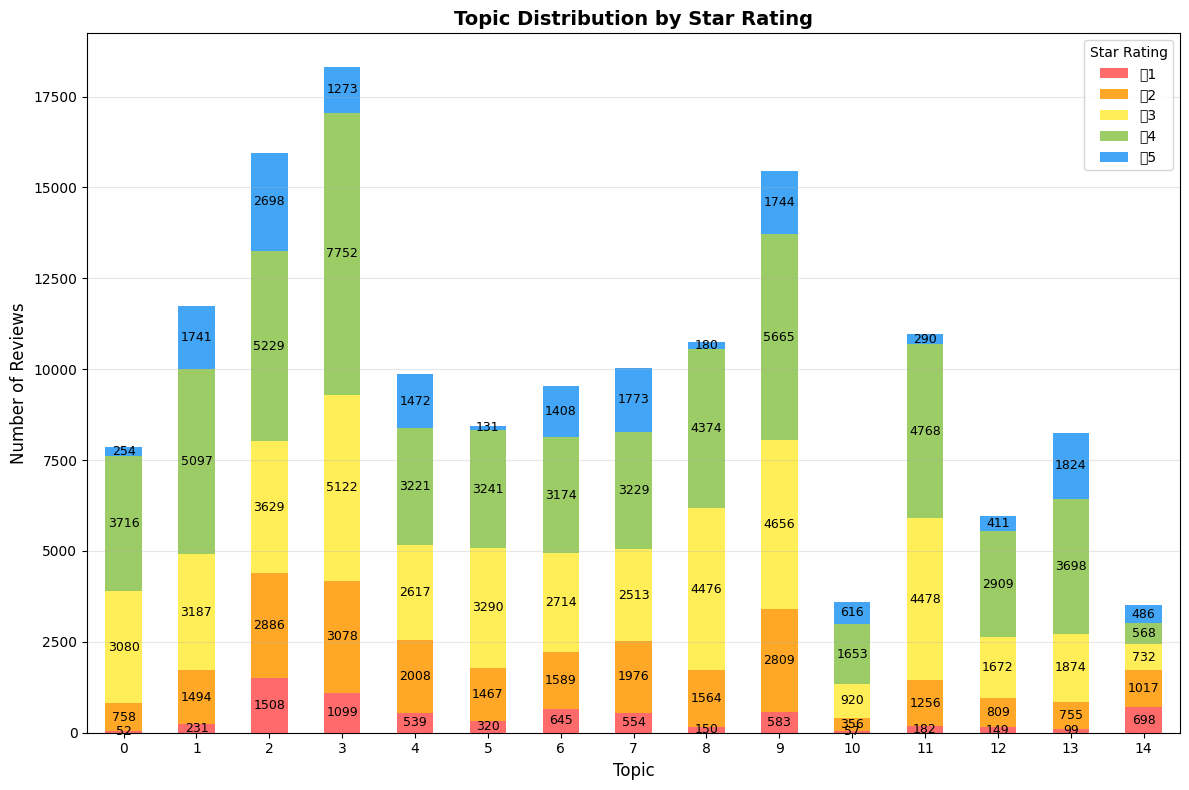

/var/folders/x2/vxndd9ls79v3xdfmnnql9ndh0000gn/T/ipykernel_30769/1118237043.py:174: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



=== Topic Analysis Summary ===
Topic 0: 3.43 ± 0.74 stars (7860 reviews)
Topic 1: 3.56 ± 0.96 stars (11750 reviews)
Topic 2: 3.30 ± 1.21 stars (15950 reviews)
Topic 3: 3.27 ± 1.02 stars (18324 reviews)
Topic 4: 3.31 ± 1.12 stars (9857 reviews)
Topic 5: 3.17 ± 0.86 stars (8449 reviews)
Topic 6: 3.33 ± 1.12 stars (9530 reviews)
Topic 7: 3.37 ± 1.14 stars (10045 reviews)
Topic 8: 3.27 ± 0.78 stars (10744 reviews)
Topic 9: 3.33 ± 1.02 stars (15457 reviews)
Topic 10: 3.67 ± 0.93 stars (3602 reviews)
Topic 11: 3.34 ± 0.78 stars (10974 reviews)
Topic 12: 3.44 ± 0.90 stars (5950 reviews)
Topic 13: 3.77 ± 0.93 stars (8250 reviews)
Topic 14: 2.75 ± 1.32 stars (3501 reviews)


/Users/mare/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


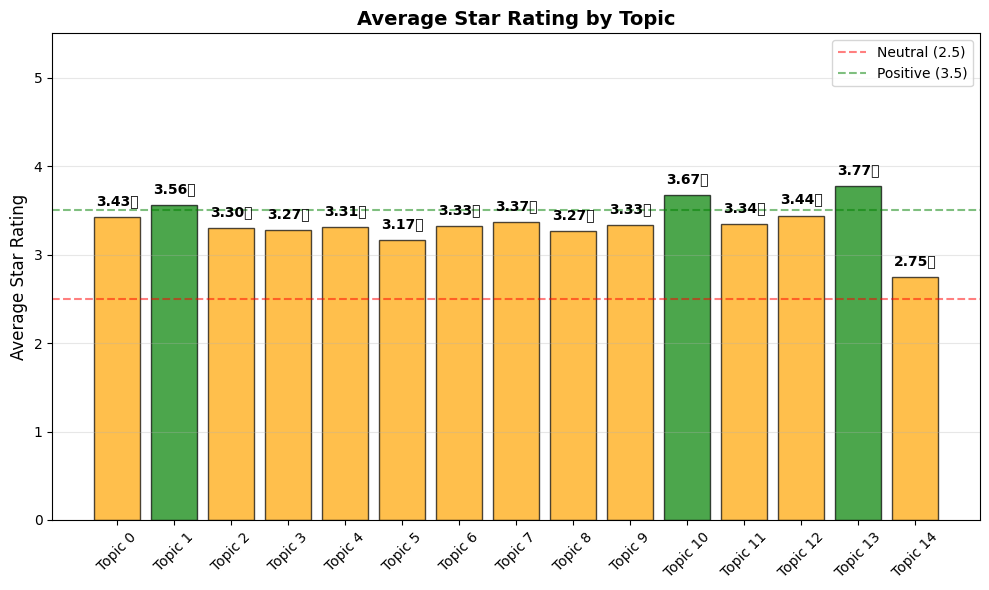

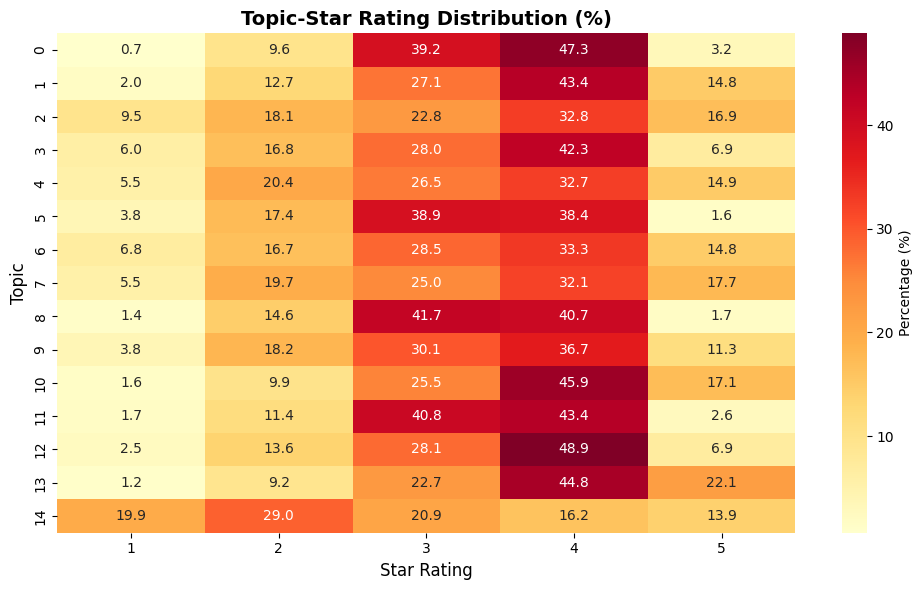

(                   business_id                      name  \
 0       Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
 1       mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
 2       tUFrWirKiKi_TAnsVWINQQ                    Target   
 3       MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
 4       mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   
 ...                        ...                       ...   
 150341  IUQopTMmYQG-qRtBk-8QnA              Binh's Nails   
 150342  c8GjPIOTGVmIemT7j5_SyQ      Wild Birds Unlimited   
 150343  _QAMST-NrQobXduilWEqSw         Claire's Boutique   
 150344  mtGm22y5c2UHNXDFAjaPNw  Cyclery & Fitness Center   
 150345  jV_XOycEzSlTx-65W906pg                   Sic Ink   
 
                                 address           city state postal_code  \
 0                1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
 1       87 Grasso Plaza Shopping Center         Affton    MO       63123   
 2                  5255 E Broadway

In [103]:
comprehensive_topic_analysis(bizdf, n_topics=15)

## 4. COnfidence Score Comparison

In [106]:
all_results = {
    'Result 1 (6 topics)': {
        0: (17138, 0.049), 1: (20614, 0.049), 2: (54039, 0.027),
        3: (27138, 0.055), 4: (10868, 0.071), 5: (20446, 0.058)
    },
    'Result 2 (8 topics)': {
        0: (16352, 0.049), 1: (12309, 0.073), 2: (36545, 0.029),
        3: (26153, 0.056), 4: (10421, 0.071), 5: (20306, 0.058),
        6: (12267, 0.064), 7: (15890, 0.049)
    },
    'Result 3 (15 topics)': {
        0: (7860, 0.048), 1: (11750, 0.074), 2: (15950, 0.033),
        3: (18324, 0.059), 4: (9857, 0.073), 5: (8449, 0.090),
        6: (9530, 0.076), 7: (10045, 0.063), 8: (10744, 0.073),
        9: (15457, 0.054), 10: (3602, 0.101), 11: (10974, 0.048),
        12: (5950, 0.085), 13: (8250, 0.061), 14: (3501, 0.112)
    },
    'Result 4 (12 topics)': {
        0: (8442, 0.051), 1: (11796, 0.074), 2: (19006, 0.036),
        3: (22048, 0.060), 4: (10454, 0.071), 5: (8597, 0.091),
        6: (10753, 0.070), 7: (14481, 0.049), 8: (10568, 0.074),
        9: (17922, 0.051), 10: (3657, 0.106), 11: (12519, 0.058)
    }
}

def analyze_results(results):
    """Comprehensive analysis of topic modeling results"""
    
    analysis = {}
    
    for result_name, topics in results.items():
        confidences = [conf for _, conf in topics.values()]
        counts = [count for count, _ in topics.values()]
        
        analysis[result_name] = {
            'num_topics': len(topics),
            'avg_confidence': np.mean(confidences),
            'median_confidence': np.median(confidences),
            'max_confidence': max(confidences),
            'min_confidence': min(confidences),
            'confidence_std': np.std(confidences),
            'avg_topic_size': np.mean(counts),
            'size_std': np.std(counts),
            'high_confidence_topics': len([c for c in confidences if c > 0.07]),
            'low_confidence_topics': len([c for c in confidences if c < 0.04])
        }
    
    return analysis

# Perform analysis
analysis = analyze_results(all_results)

print("=== COMPREHENSIVE COMPARISON ===")
for result_name, stats in analysis.items():
    print(f"\n{result_name}:")
    print(f"  Topics: {stats['num_topics']}")
    print(f"  Avg Confidence: {stats['avg_confidence']:.3f}")
    print(f"  Max Confidence: {stats['max_confidence']:.3f}")
    print(f"  High Confidence Topics (>0.07): {stats['high_confidence_topics']}")
    print(f"  Topic Size Std: {stats['size_std']:.0f} (lower = better balanced)")

=== COMPREHENSIVE COMPARISON ===

Result 1 (6 topics):
  Topics: 6
  Avg Confidence: 0.051
  Max Confidence: 0.071
  High Confidence Topics (>0.07): 1
  Topic Size Std: 13840 (lower = better balanced)

Result 2 (8 topics):
  Topics: 8
  Avg Confidence: 0.056
  Max Confidence: 0.073
  High Confidence Topics (>0.07): 2
  Topic Size Std: 8221 (lower = better balanced)

Result 3 (15 topics):
  Topics: 15
  Avg Confidence: 0.070
  Max Confidence: 0.112
  High Confidence Topics (>0.07): 8
  Topic Size Std: 4073 (lower = better balanced)

Result 4 (12 topics):
  Topics: 12
  Avg Confidence: 0.066
  Max Confidence: 0.106
  High Confidence Topics (>0.07): 5
  Topic Size Std: 4900 (lower = better balanced)
